# Seasonal Agriculture Performance Analysis

## VOIS Data Analytics Major Project

### Objective
To analyze agricultural performance across different seasons and identify meaningful patterns, trends, relationships, and variations using data analytics.


## Problem Statement

To analyze agricultural performance across different seasons, crops, regions, irrigation methods, and farming conditions, and identify meaningful patterns, trends, relationships, and variations that can support better agricultural planning and decision-making.

## Project Objectives

- Explore and understand the agricultural dataset.
- Clean and prepare the data for analysis.
- Compare agricultural performance across seasons and crops.
- Analyze irrigation methods, resource usage, and water efficiency.
- Examine relationships between environmental conditions and agricultural outcomes.
- Identify significant differences and unusual patterns using statistical analysis.
- Evaluate profitability and identify high- and low-performing crop-season combinations.
- Provide data-driven recommendations for agricultural planning.

## Technology Used

- Python
- Google Colab / Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy
- Statsmodels
- Excel Dataset

## Project Overview

This project analyzes agricultural performance across different seasons, crops, irrigation methods, and environmental conditions. The analysis focuses on identifying meaningful patterns in yield, production, profitability, water efficiency, and disease-pest risk using statistical analysis and data visualization.

## Data Understanding

The dataset contains 4,000 agricultural farm records and 28 variables covering farm characteristics, environmental conditions, farming inputs, yield, production, market price, costs, revenue, profit, water usage, water efficiency, and disease-pest risk.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset (2).xlsx to seasonal_agriculture_performance_dataset (2).xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_excel("seasonal_agriculture_performance_dataset (2).xlsx")

In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.shape

(4000, 28)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [ ]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [ ]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [ ]:
df.isnull().sum().sum()

np.int64(120)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Farm_ID"].duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
state_district = df.groupby("State")["District"].unique()

for state, districts in state_district.items():
    print(f"{state}: {list(districts)}")

Andhra Pradesh: ['Rajkot', 'Warangal', 'Raichur', 'Nalgonda', 'Guntur', 'Ludhiana', 'Erode', 'Nashik', 'Indore', 'Krishna']
Gujarat: ['Raichur', 'Indore', 'Erode', 'Ludhiana', 'Guntur', 'Warangal', 'Krishna', 'Rajkot', 'Nashik', 'Nalgonda']
Karnataka: ['Ludhiana', 'Guntur', 'Indore', 'Krishna', 'Warangal', 'Nashik', 'Erode', 'Raichur', 'Nalgonda', 'Rajkot']
Madhya Pradesh: ['Krishna', 'Indore', 'Ludhiana', 'Erode', 'Raichur', 'Nalgonda', 'Warangal', 'Guntur', 'Rajkot', 'Nashik']
Maharashtra: ['Nalgonda', 'Krishna', 'Ludhiana', 'Erode', 'Rajkot', 'Guntur', 'Indore', 'Raichur', 'Nashik', 'Warangal']
Punjab: ['Indore', 'Nalgonda', 'Ludhiana', 'Krishna', 'Rajkot', 'Nashik', 'Erode', 'Guntur', 'Warangal', 'Raichur']
Tamil Nadu: ['Ludhiana', 'Raichur', 'Rajkot', 'Nalgonda', 'Erode', 'Warangal', 'Krishna', 'Guntur', 'Nashik', 'Indore']
Telangana: ['Warangal', 'Indore', 'Rajkot', 'Nashik', 'Nalgonda', 'Erode', 'Guntur', 'Krishna', 'Ludhiana', 'Raichur']


In [ ]:
missing_cols = df.columns[df.isnull().any()]

for col in missing_cols:
    print(f"\n{col}")
    print(df[df[col].isnull()][["State", "District", "Crop", "Season", col]].head(10))


Rainfall_mm
              State  District       Crop  Season  Rainfall_mm
186      Tamil Nadu    Indore       Rice    Rabi          NaN
253      Tamil Nadu  Ludhiana  Sugarcane    Zaid          NaN
271       Karnataka     Erode  Groundnut  Kharif          NaN
272          Punjab    Rajkot      Maize    Rabi          NaN
287         Gujarat    Guntur      Wheat    Rabi          NaN
408       Telangana   Raichur      Wheat  Kharif          NaN
496      Tamil Nadu    Rajkot     Pulses    Zaid          NaN
520         Gujarat  Ludhiana     Pulses    Rabi          NaN
594  Madhya Pradesh  Ludhiana     Chilli    Zaid          NaN
807     Maharashtra  Nalgonda     Pulses    Zaid          NaN

Soil_Moisture_pct
               State  District       Crop  Season  Soil_Moisture_pct
28        Tamil Nadu    Rajkot      Maize    Rabi                NaN
43        Tamil Nadu     Erode      Wheat    Rabi                NaN
121      Maharashtra     Erode     Cotton  Kharif                NaN
196   Andh

In [ ]:
df[df.isnull().any(axis=1)].groupby("Season").size()

,0
Season,
Kharif,44
Rabi,51
Zaid,25


In [ ]:
df["Rainfall_mm"] = df.groupby(["Crop", "Season"])["Rainfall_mm"].transform(
    lambda x: x.fillna(x.median())
)

df["Soil_Moisture_pct"] = df.groupby(["Crop", "Season"])["Soil_Moisture_pct"].transform(
    lambda x: x.fillna(x.median())
)

df["Yield_Tonnes_Ha"] = df.groupby(["Crop", "Season"])["Yield_Tonnes_Ha"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Farm_Area_Hectares: 0 outliers
Rainfall_mm: 0 outliers
Avg_Temperature_C: 2 outliers
Humidity_pct: 6 outliers
Sunlight_Hours_Day: 26 outliers
Soil_pH: 0 outliers
Soil_Moisture_pct: 3 outliers
Nitrogen_kg_ha: 10 outliers
Phosphorus_kg_ha: 16 outliers
Potassium_kg_ha: 32 outliers
Fertilizer_kg_ha: 15 outliers
Pesticide_Litre_ha: 8 outliers
Seed_Quality_Score: 0 outliers
Yield_Tonnes_Ha: 304 outliers
Production_Tonnes: 333 outliers
Market_Price_INR_Tonne: 0 outliers
Total_Cost_INR: 0 outliers
Revenue_INR: 240 outliers
Profit_INR: 404 outliers
Water_Used_m3: 276 outliers
Water_Efficiency_t_per_1000m3: 322 outliers
Disease_Pest_Risk_pct: 10 outliers


In [ ]:
df_clean = df.copy()

In [ ]:
df_clean.shape

(4000, 28)

In [ ]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.720675,288.420788,80.000,370.425,581.0000,835.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.505913,6.695965,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [ ]:
df_clean.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:
df_clean.describe(include="object").T

,count,unique,top,freq
Farm_ID,4000,4000,SF13984,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [ ]:
for col in ["State", "District", "Crop", "Season", "Irrigation_Method"]:
    print(f"\n{col}")
    print(df_clean[col].value_counts())


State
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


In [ ]:
yield_summary = df_clean.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

yield_summary

,count,mean,median,min,max
Season,,,,,
Kharif,1779,5.63,1.95,0.3,101.44
Rabi,1627,5.09,1.66,0.3,93.13
Zaid,594,4.64,1.45,0.3,64.76


In [ ]:
crop_yield = df_clean.groupby("Crop")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False).round(2)

crop_yield

,count,mean,median,min,max
Crop,,,,,
Sugarcane,305,46.93,47.88,1.39,101.44
Maize,551,2.72,2.84,0.30,6.08
Rice,690,2.44,2.46,0.30,5.70
Wheat,614,2.11,2.23,0.30,4.56
Chilli,412,1.54,1.56,0.30,3.90
Groundnut,424,1.32,1.38,0.30,3.02
Cotton,508,1.23,1.23,0.30,2.90
Pulses,496,0.92,0.94,0.30,2.09


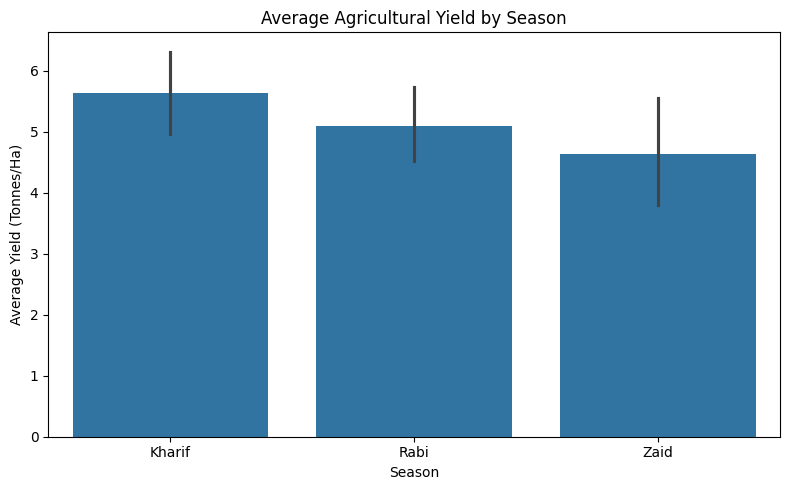

In [ ]:
plt.figure(figsize=(8, 5))

season_order = ["Kharif", "Rabi", "Zaid"]

sns.barplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha",
    order=season_order,
    estimator="mean"
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

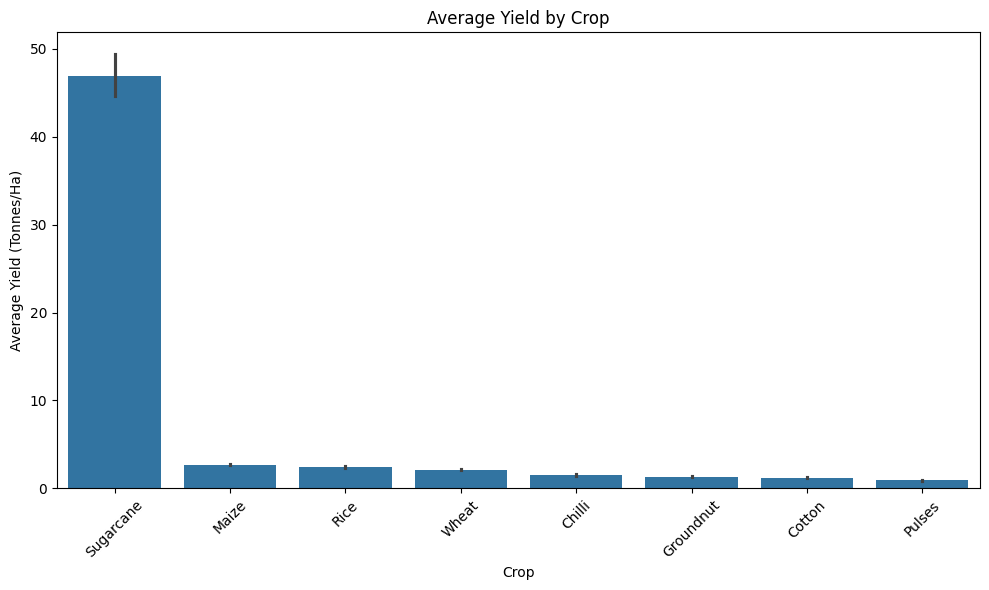

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="Crop",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    order=crop_yield.index
)

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
season_kpi = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

season_kpi

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,
Kharif,5.63,46.31,178914.65,5.89,54.47
Rabi,5.09,41.49,87689.47,5.19,40.48
Zaid,4.64,38.89,-24804.82,4.41,38.22


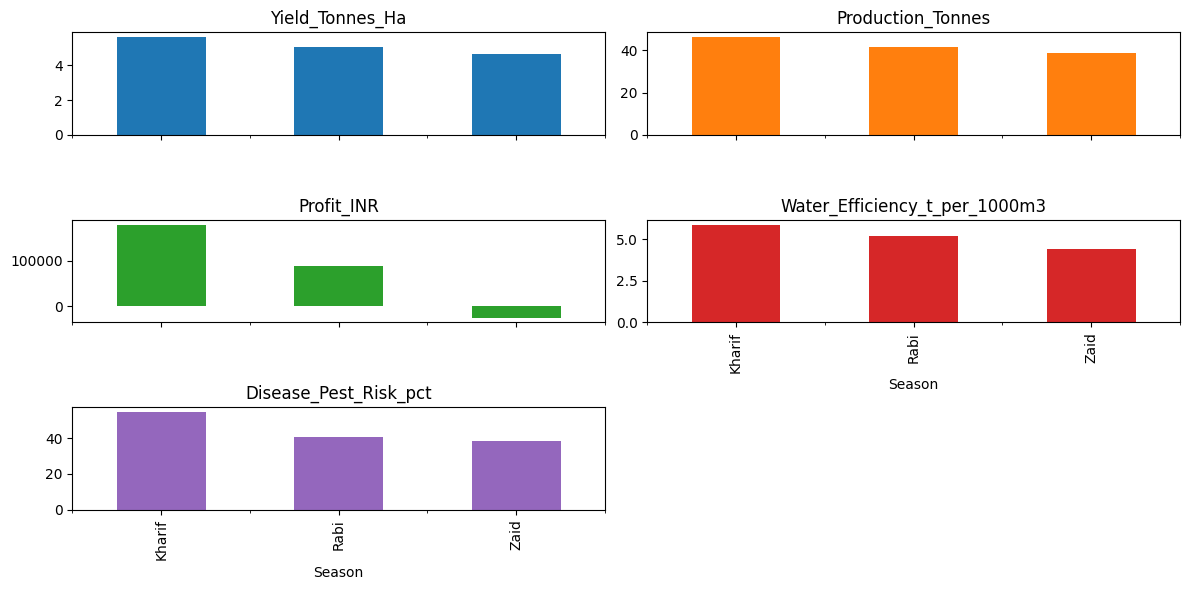

In [ ]:
season_kpi.plot(kind="bar", figsize=(12, 6), subplots=True, layout=(3, 2), legend=False)

plt.tight_layout()
plt.show()

In [ ]:
environment_kpi = df_clean.groupby("Season").agg({
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Humidity_pct": "mean",
    "Sunlight_Hours_Day": "mean",
    "Soil_Moisture_pct": "mean",
    "Soil_pH": "mean"
}).round(2)

environment_kpi

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20,6.73
Rabi,435.95,23.49,57.89,7.59,24.05,6.67
Zaid,299.16,31.04,52.01,8.18,19.18,6.69


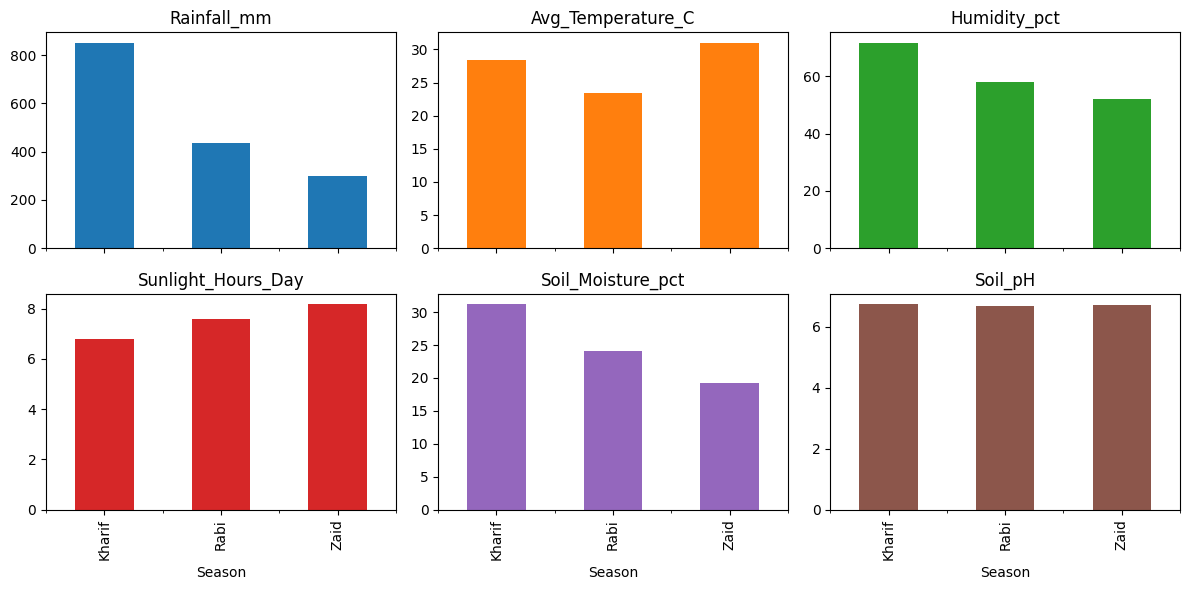

In [ ]:
environment_kpi.plot(
    kind="bar",
    figsize=(12, 6),
    subplots=True,
    layout=(2, 3),
    legend=False
)

plt.tight_layout()
plt.show()

In [ ]:
resource_kpi = df_clean.groupby("Season").agg({
    "Fertilizer_kg_ha": "mean",
    "Pesticide_Litre_ha": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).round(2)

resource_kpi

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


In [ ]:
irrigation_season = pd.crosstab(
    df_clean["Season"],
    df_clean["Irrigation_Method"]
)

irrigation_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [ ]:
economic_kpi = df_clean.groupby("Season").agg({
    "Market_Price_INR_Tonne": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean"
}).round(2)

economic_kpi

,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


In [ ]:
profit_status = df_clean.groupby("Season")["Profit_INR"].agg(
    total="sum",
    average="mean",
    median="median",
    profitable=lambda x: (x > 0).sum(),
    loss_making=lambda x: (x < 0).sum()
).round(2)

profit_status

,total,average,median,profitable,loss_making
Season,,,,,
Kharif,318289158,178914.65,38808.0,1028,751
Rabi,142670768,87689.47,-3187.0,795,832
Zaid,-14734066,-24804.82,-62144.0,211,383


In [ ]:
crop_economic = df_clean.groupby("Crop").agg({
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Market_Price_INR_Tonne": "mean"
}).sort_values("Profit_INR", ascending=False).round(2)

crop_economic

,Revenue_INR,Total_Cost_INR,Profit_INR,Market_Price_INR_Tonne
Crop,,,,
Sugarcane,1371980.11,554792.13,817187.99,3490.25
Chilli,1276777.23,525898.89,750878.34,103372.94
Cotton,639423.08,514876.17,124546.92,67921.11
Groundnut,542935.50,498077.38,44858.12,56310.06
Pulses,528465.87,532703.92,-4238.05,71431.61
Maize,457067.99,541046.32,-83978.33,20990.55
Rice,423615.26,525828.76,-102213.50,22023.13
Wheat,400104.89,523503.22,-123398.34,23829.43


In [ ]:
crop_profit_status = df_clean.groupby("Crop")["Profit_INR"].agg(
    profitable=lambda x: (x > 0).sum(),
    loss_making=lambda x: (x < 0).sum()
)

crop_profit_status["profitability_rate_%"] = (
    crop_profit_status["profitable"] /
    (crop_profit_status["profitable"] + crop_profit_status["loss_making"])
    * 100
).round(2)

crop_profit_status.sort_values("profitability_rate_%", ascending=False)

,profitable,loss_making,profitability_rate_%
Crop,,,
Sugarcane,270,35,88.52
Chilli,338,74,82.04
Cotton,332,176,65.35
Groundnut,251,173,59.20
Pulses,252,244,50.81
Maize,200,351,36.30
Rice,232,458,33.62
Wheat,159,455,25.90


In [ ]:
environment_yield = df_clean[[
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Soil_pH",
    "Yield_Tonnes_Ha"
]].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

environment_yield

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Rainfall_mm,0.026858
Humidity_pct,0.010651
Soil_Moisture_pct,0.010065
Avg_Temperature_C,0.009153
Sunlight_Hours_Day,-0.015462
Soil_pH,-0.021767


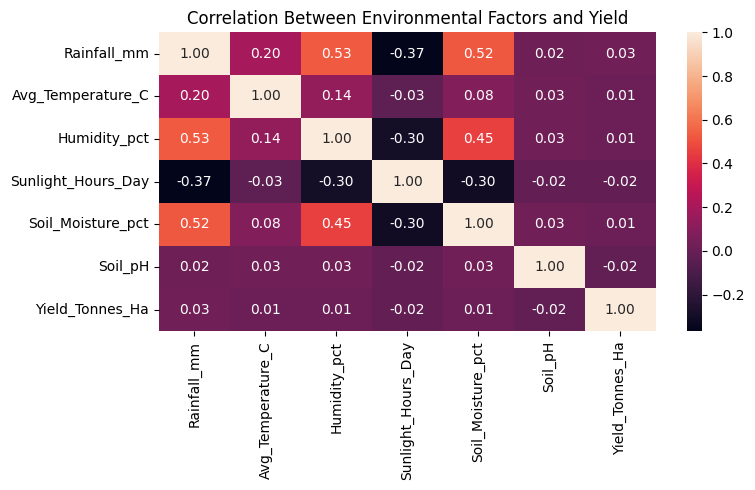

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df_clean[[
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_Moisture_pct",
        "Soil_pH",
        "Yield_Tonnes_Ha"
    ]].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Environmental Factors and Yield")
plt.tight_layout()
plt.show()

In [ ]:
farming_yield = df_clean[[
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha"
]].corr()["Yield_Tonnes_Ha"].sort_values(ascending=False)

farming_yield

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Nitrogen_kg_ha,0.053633
Phosphorus_kg_ha,0.046685
Potassium_kg_ha,0.005127
Fertilizer_kg_ha,-0.000414
Seed_Quality_Score,-0.007764
Pesticide_Litre_ha,-0.008598


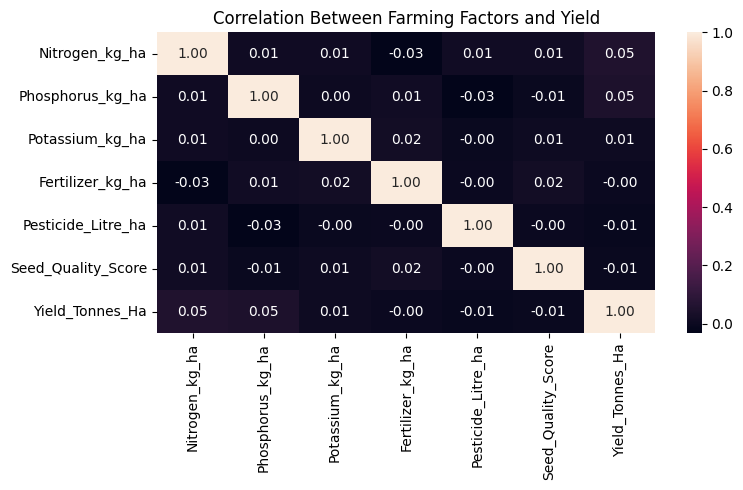

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df_clean[[
        "Nitrogen_kg_ha",
        "Phosphorus_kg_ha",
        "Potassium_kg_ha",
        "Fertilizer_kg_ha",
        "Pesticide_Litre_ha",
        "Seed_Quality_Score",
        "Yield_Tonnes_Ha"
    ]].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Farming Factors and Yield")
plt.tight_layout()
plt.show()

In [ ]:
irrigation_yield = df_clean.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False).round(2)

irrigation_yield

,count,mean,median,min,max
Irrigation_Method,,,,,
Drip,915,6.67,1.96,0.3,101.44
Sprinkler,734,5.16,1.80,0.3,84.75
Flood,1310,4.86,1.63,0.3,91.46
Rainfed,1041,4.60,1.72,0.3,77.32


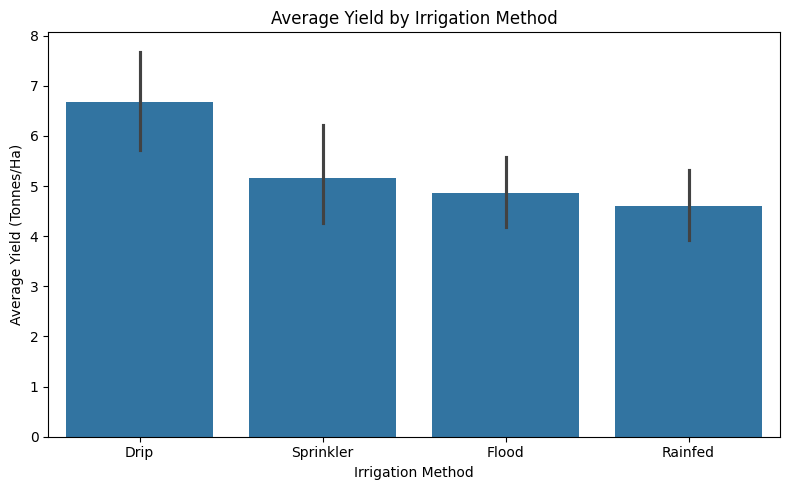

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    estimator="mean",
    order=irrigation_yield.index
)

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [ ]:
irrigation_economic = df_clean.groupby("Irrigation_Method").agg({
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).sort_values("Profit_INR", ascending=False).round(2)

irrigation_economic

,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,,,,
Drip,754571.23,534945.24,219626.00,5918.75,6.27
Sprinkler,617730.30,526609.22,91121.08,6208.26,4.67
Rainfed,584353.98,505303.61,79050.37,3549.55,7.56
Flood,610138.15,536784.13,73354.02,8026.47,3.44


In [ ]:
irrigation_profit = df_clean.groupby("Irrigation_Method")["Profit_INR"].agg(
    profitable=lambda x: (x > 0).sum(),
    loss_making=lambda x: (x < 0).sum()
)

irrigation_profit["profitability_rate_%"] = (
    irrigation_profit["profitable"] /
    (irrigation_profit["profitable"] + irrigation_profit["loss_making"])
    * 100
).round(2)

irrigation_profit.sort_values("profitability_rate_%", ascending=False)

,profitable,loss_making,profitability_rate_%
Irrigation_Method,,,
Drip,547,368,59.78
Sprinkler,381,353,51.91
Flood,618,692,47.18
Rainfed,488,553,46.88


In [ ]:
season_crop_yield = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

season_crop_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.62,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.96,38.42
Wheat,2.26,2.06,1.75


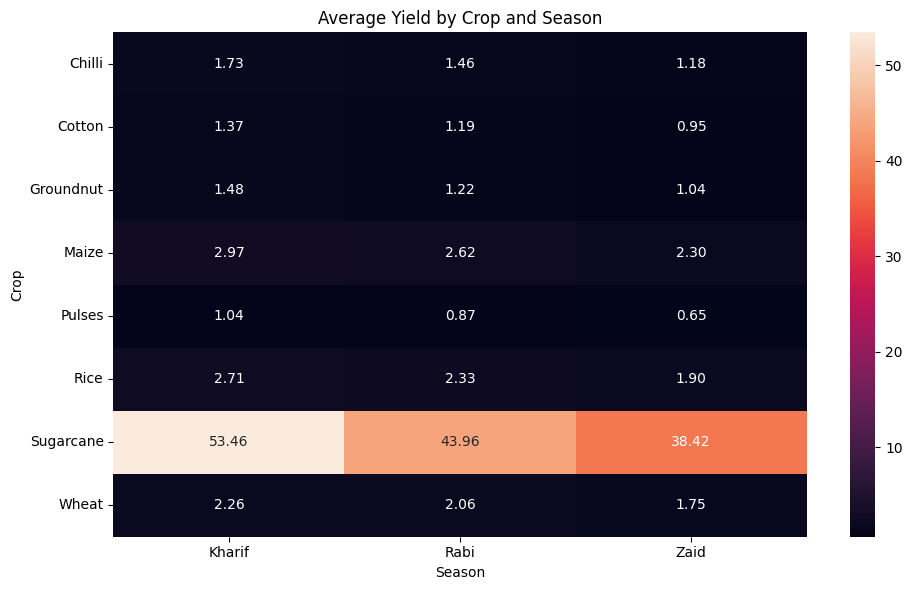

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [ ]:
production_season = df_clean.groupby("Season")["Production_Tonnes"].agg(
    ["count", "mean", "median", "min", "max", "sum"]
).round(2)

production_season

,count,mean,median,min,max,sum
Season,,,,,,
Kharif,1779,46.31,13.24,0.20,1424.40,82387.61
Rabi,1627,41.49,11.08,0.19,1249.21,67498.88
Zaid,594,38.89,9.97,0.15,956.73,23098.35


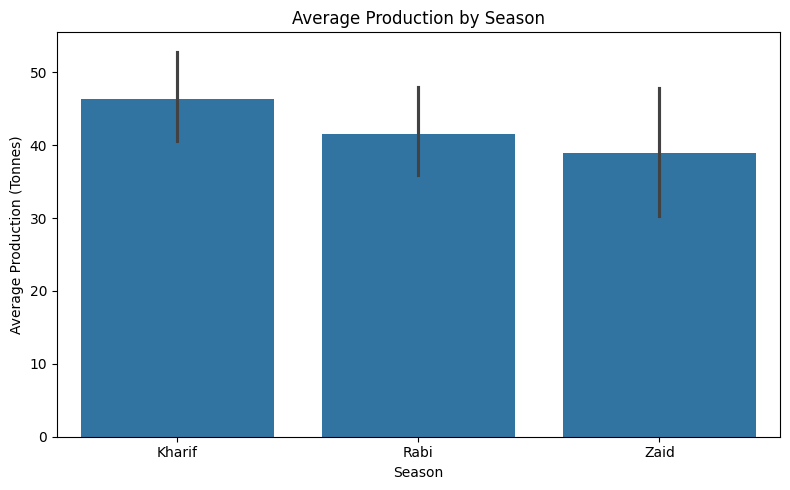

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="Season",
    y="Production_Tonnes",
    order=["Kharif", "Rabi", "Zaid"],
    estimator="mean"
)

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.tight_layout()
plt.show()

In [ ]:
season_irrigation_yield = df_clean.pivot_table(
    values="Yield_Tonnes_Ha",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
).round(2)

season_irrigation_yield

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.35,5.85
Flood,4.98,5.06,3.97
Rainfed,5.70,3.93,3.06
Sprinkler,4.67,5.31,6.14


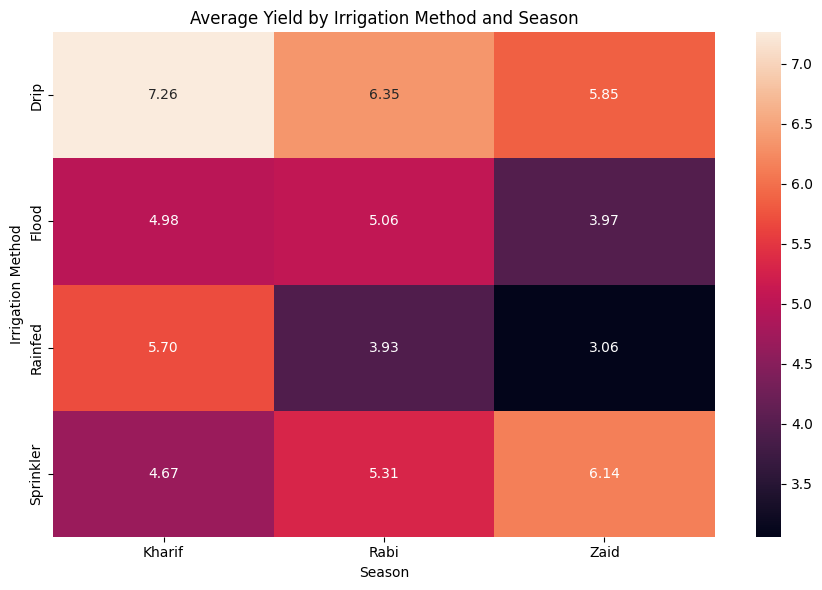

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    season_irrigation_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Yield by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")
plt.tight_layout()
plt.show()

In [ ]:
water_season = df_clean.groupby("Season").agg({
    "Water_Used_m3": ["mean", "median"],
    "Water_Efficiency_t_per_1000m3": ["mean", "median"]
}).round(2)

water_season

Water_Used_m3         Water_Efficiency_t_per_1000m3       
                mean  median                          mean median
Season                                                           
Kharif       6102.20  4469.0                          5.89   3.28
Rabi         5846.99  4292.0                          5.19   2.74
Zaid         6419.89  4805.0                          4.41   2.30

In [ ]:
water_irrigation = df_clean.groupby("Irrigation_Method").agg({
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean"
}).sort_values("Water_Efficiency_t_per_1000m3", ascending=False).round(2)

water_irrigation

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Irrigation_Method,,
Rainfed,3549.55,7.56
Drip,5918.75,6.27
Sprinkler,6208.26,4.67
Flood,8026.47,3.44


In [ ]:
risk_season = df_clean.groupby("Season")["Disease_Pest_Risk_pct"].agg(
    ["mean", "median", "min", "max"]
).round(2)

risk_season

,mean,median,min,max
Season,,,,
Kharif,54.47,54.5,21.3,88.9
Rabi,40.48,40.6,5.1,71.2
Zaid,38.22,37.9,5.0,71.6


In [ ]:
risk_crop = df_clean.groupby("Crop")["Disease_Pest_Risk_pct"].agg(
    ["mean", "median", "min", "max"]
).sort_values("mean", ascending=False).round(2)

risk_crop

,mean,median,min,max
Crop,,,,
Wheat,47.85,47.50,13.1,83.2
Pulses,46.57,46.75,12.9,76.9
Rice,46.50,46.35,16.2,87.7
Groundnut,46.29,45.90,5.0,82.8
Chilli,46.06,46.00,5.1,79.1
Cotton,45.97,46.25,12.6,82.3
Maize,45.54,45.30,14.1,79.8
Sugarcane,45.40,45.30,17.1,88.9


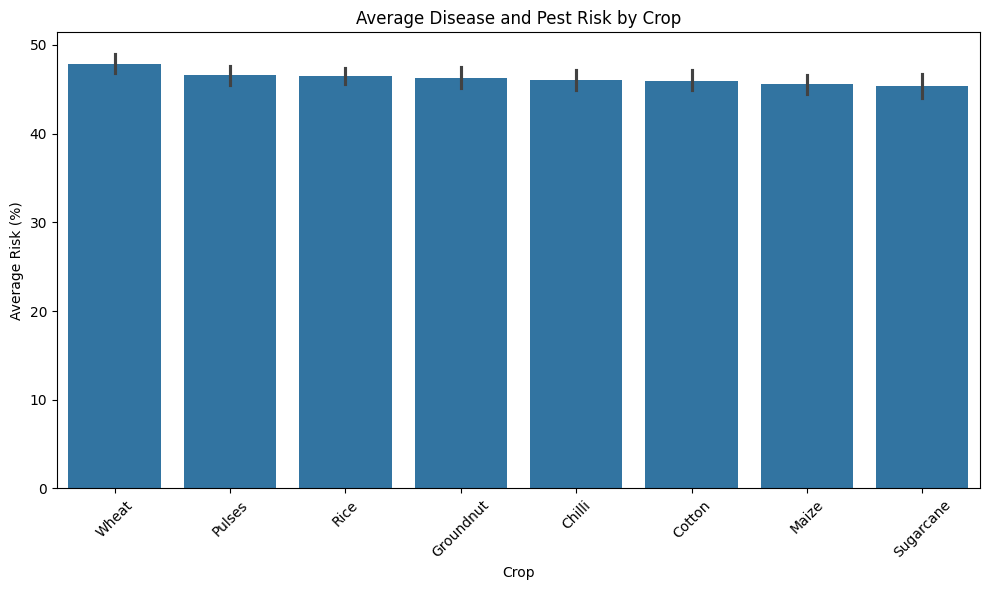

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_clean,
    x="Crop",
    y="Disease_Pest_Risk_pct",
    estimator="mean",
    order=risk_crop.index
)

plt.title("Average Disease and Pest Risk by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
profit_corr = df_clean.select_dtypes(include=np.number).corr()["Profit_INR"].sort_values(ascending=False)

profit_corr

,Profit_INR
Profit_INR,1.000000
Revenue_INR,0.887331
Production_Tonnes,0.554172
Water_Efficiency_t_per_1000m3,0.489487
Yield_Tonnes_Ha,0.489350
Market_Price_INR_Tonne,0.225119
Water_Used_m3,0.190278
Farm_Area_Hectares,0.115241
Rainfall_mm,0.105972
Soil_Moisture_pct,0.092204


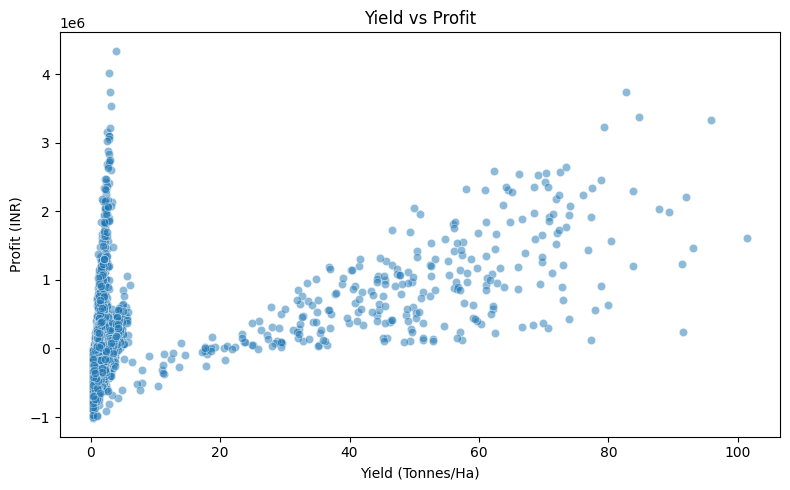

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_clean,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    alpha=0.5
)

plt.title("Yield vs Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

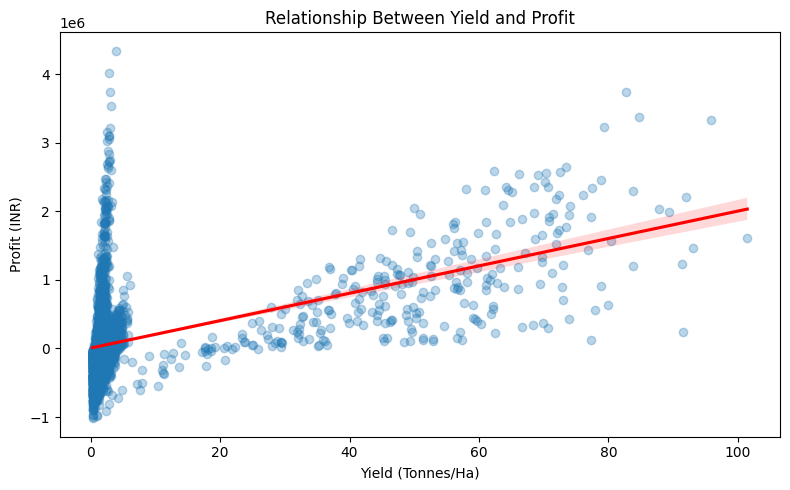

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df_clean,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Relationship Between Yield and Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

In [ ]:
season_irrigation_profit = df_clean.pivot_table(
    values="Profit_INR",
    index="Irrigation_Method",
    columns="Season",
    aggfunc="mean"
).round(2)

season_irrigation_profit

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,317222.07,187843.22,21291.84
Flood,133373.83,58824.80,-69786.78
Rainfed,158974.13,45232.48,-79467.26
Sprinkler,116880.49,76502.07,57909.40


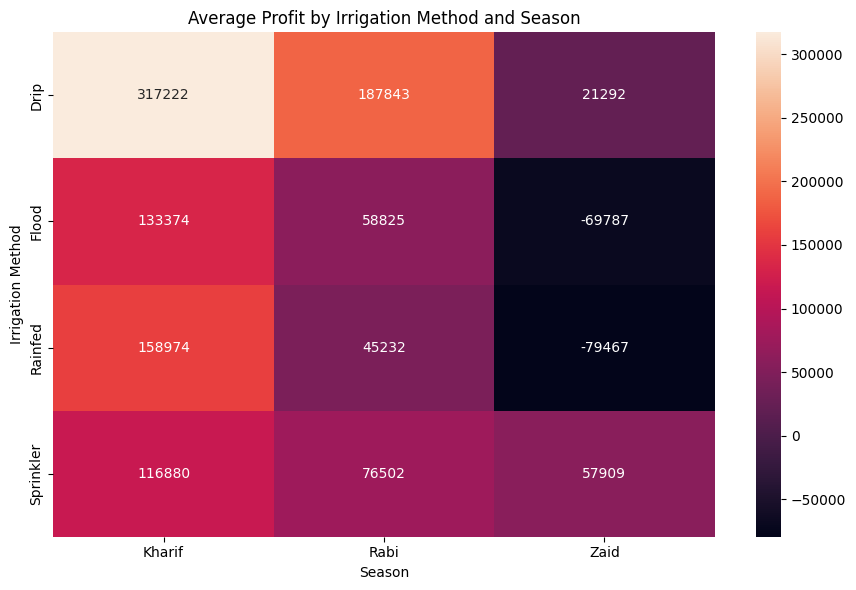

In [ ]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    season_irrigation_profit,
    annot=True,
    fmt=".0f"
)

plt.title("Average Profit by Irrigation Method and Season")
plt.xlabel("Season")
plt.ylabel("Irrigation Method")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import f_oneway

kharif = df_clean[df_clean["Season"] == "Kharif"]["Yield_Tonnes_Ha"]
rabi = df_clean[df_clean["Season"] == "Rabi"]["Yield_Tonnes_Ha"]
zaid = df_clean[df_clean["Season"] == "Zaid"]["Yield_Tonnes_Ha"]

f_stat, p_value = f_oneway(kharif, rabi, zaid)

print("F-statistic:", round(f_stat, 4))
print("P-value:", round(p_value, 6))

F-statistic: 1.4579
P-value: 0.232847


In [ ]:
if p_value < 0.05:
    print("Result: Seasonal yield differences are statistically significant.")
else:
    print("Result: No statistically significant seasonal yield difference.")

Result: No statistically significant seasonal yield difference.


In [ ]:
from scipy.stats import f_oneway

kharif_profit = df_clean[df_clean["Season"] == "Kharif"]["Profit_INR"]
rabi_profit = df_clean[df_clean["Season"] == "Rabi"]["Profit_INR"]
zaid_profit = df_clean[df_clean["Season"] == "Zaid"]["Profit_INR"]

f_stat_profit, p_value_profit = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("F-statistic:", round(f_stat_profit, 4))
print("P-value:", round(p_value_profit, 6))

F-statistic: 34.2918
P-value: 0.0


In [ ]:
if p_value_profit < 0.05:
    print("Result: Seasonal profit differences are statistically significant.")
else:
    print("Result: No statistically significant seasonal profit difference.")

Result: Seasonal profit differences are statistically significant.


In [ ]:
profitability_by_season = df_clean.groupby("Season")["Profit_INR"].agg(
    profitable=lambda x: (x > 0).sum(),
    loss_making=lambda x: (x < 0).sum()
)

profitability_by_season["profitability_rate_%"] = (
    profitability_by_season["profitable"] /
    (profitability_by_season["profitable"] + profitability_by_season["loss_making"])
    * 100
).round(2)

profitability_by_season

,profitable,loss_making,profitability_rate_%
Season,,,
Kharif,1028,751,57.79
Rabi,795,832,48.86
Zaid,211,383,35.52


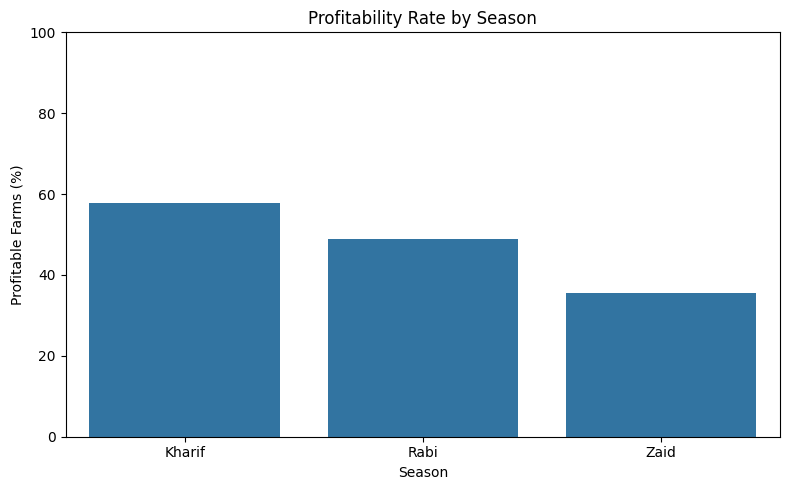

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=profitability_by_season.index,
    y=profitability_by_season["profitability_rate_%"]
)

plt.title("Profitability Rate by Season")
plt.xlabel("Season")
plt.ylabel("Profitable Farms (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
crop_season_profit = df_clean.pivot_table(
    values="Profit_INR",
    index="Crop",
    columns="Season",
    aggfunc="mean"
).round(2)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


In [ ]:
best_by_season = pd.DataFrame({
    "Best_Crop": crop_season_profit.idxmax(),
    "Average_Profit_INR": crop_season_profit.max()
}).round(2)

best_by_season

,Best_Crop,Average_Profit_INR
Season,,
Kharif,Sugarcane,1000790.81
Rabi,Sugarcane,731612.86
Zaid,Sugarcane,583635.80


In [ ]:
crop_season_profit_rate = df_clean.groupby(
    ["Crop", "Season"]
)["Profit_INR"].agg(
    profitable=lambda x: (x > 0).sum(),
    total="count"
)

crop_season_profit_rate["profitability_rate_%"] = (
    crop_season_profit_rate["profitable"] /
    crop_season_profit_rate["total"] * 100
).round(2)

crop_season_profit_rate

profitable  total  profitability_rate_%
Crop      Season                                         
Chilli    Kharif         158    185                 85.41
          Rabi           128    163                 78.53
          Zaid            52     64                 81.25
Cotton    Kharif         155    215                 72.09
          Rabi           133    201                 66.17
          Zaid            44     92                 47.83
Groundnut Kharif         129    193                 66.84
          Rabi           100    177                 56.50
          Zaid            22     54                 40.74
Maize     Kharif         109    234                 46.58
          Rabi            78    233                 33.48
          Zaid            13     84                 15.48
Pulses    Kharif         139    221                 62.90
          Rabi            98    213                 46.01
          Zaid            15     62                 24.19
Rice      Kharif         130    314                 41.40
          Rabi            89    274                 32.48
          Zaid            13    102                 12.75
Sugarcane Kharif         115    125                 92.00
          Rabi           110    129                 85.27
          Zaid            45     51                 88.24
Wheat     Kharif          93    292                 31.85
          Rabi            59    237                 24.89
          Zaid             7     85                  8.24

In [ ]:
crop_season_profit_rate["profitability_rate_%"].unstack()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,85.41,78.53,81.25
Cotton,72.09,66.17,47.83
Groundnut,66.84,56.50,40.74
Maize,46.58,33.48,15.48
Pulses,62.90,46.01,24.19
Rice,41.40,32.48,12.75
Sugarcane,92.00,85.27,88.24
Wheat,31.85,24.89,8.24


In [ ]:
from scipy.stats import f_oneway

drip_yield = df_clean[df_clean["Irrigation_Method"] == "Drip"]["Yield_Tonnes_Ha"]
sprinkler_yield = df_clean[df_clean["Irrigation_Method"] == "Sprinkler"]["Yield_Tonnes_Ha"]
flood_yield = df_clean[df_clean["Irrigation_Method"] == "Flood"]["Yield_Tonnes_Ha"]
rainfed_yield = df_clean[df_clean["Irrigation_Method"] == "Rainfed"]["Yield_Tonnes_Ha"]

f_stat_irrigation, p_value_irrigation = f_oneway(
    drip_yield,
    sprinkler_yield,
    flood_yield,
    rainfed_yield
)

print("F-statistic:", round(f_stat_irrigation, 4))
print("P-value:", round(p_value_irrigation, 6))

F-statistic: 4.6706
P-value: 0.00292


In [ ]:
if p_value_irrigation < 0.05:
    print("Result: Yield differences across irrigation methods are statistically significant.")
else:
    print("Result: No statistically significant yield difference across irrigation methods.")

Result: Yield differences across irrigation methods are statistically significant.


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_irrigation = pairwise_tukeyhsd(
    endog=df_clean["Yield_Tonnes_Ha"],
    groups=df_clean["Irrigation_Method"],
    alpha=0.05
)

print(tukey_irrigation)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
   Drip     Flood   -1.809 0.0089 -3.2843 -0.3337   True
   Drip   Rainfed  -2.0691 0.0034 -3.6208 -0.5174   True
   Drip Sprinkler  -1.5102 0.1011 -3.2069  0.1865  False
  Flood   Rainfed  -0.2601 0.9656 -1.6819  1.1616  False
  Flood Sprinkler   0.2988 0.9622   -1.28  1.8775  False
Rainfed Sprinkler   0.5589 0.8202 -1.0915  2.2093  False
--------------------------------------------------------


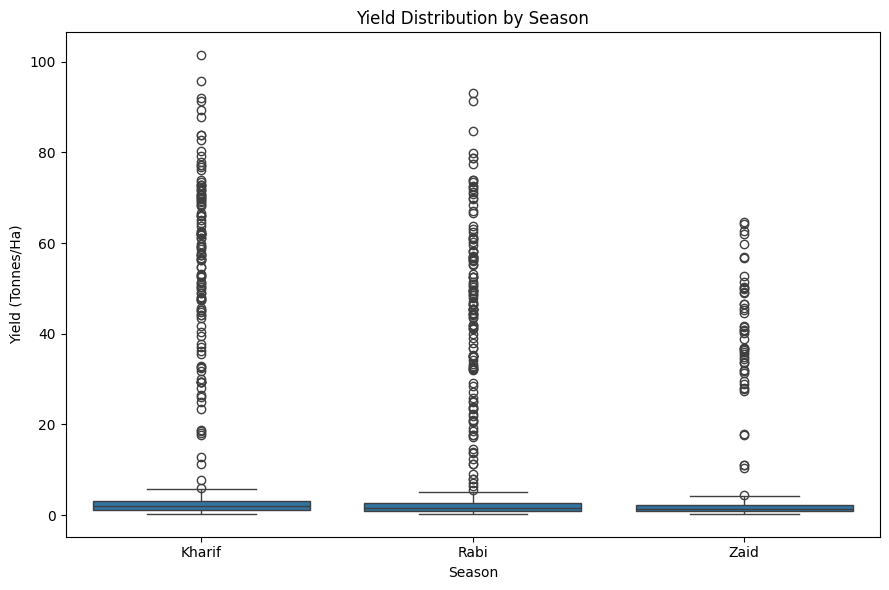

In [ ]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [ ]:
df_clean.groupby("Season")["Yield_Tonnes_Ha"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,5.63,14.39,0.3,1.18,1.95,3.10,101.44
Rabi,1627.0,5.09,12.83,0.3,1.02,1.66,2.74,93.13
Zaid,594.0,4.64,11.27,0.3,0.85,1.45,2.28,64.76


In [ ]:
df_non_sugarcane = df_clean[df_clean["Crop"] != "Sugarcane"].copy()

season_yield_no_sugarcane = df_non_sugarcane.groupby("Season")["Yield_Tonnes_Ha"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

season_yield_no_sugarcane

,count,mean,median,std,min,max
Season,,,,,,
Kharif,1654,2.02,1.82,1.17,0.3,6.08
Rabi,1498,1.75,1.54,1.02,0.3,5.44
Zaid,543,1.46,1.33,0.86,0.3,4.44


In [ ]:
kharif_ns = df_non_sugarcane[
    df_non_sugarcane["Season"] == "Kharif"
]["Yield_Tonnes_Ha"]

rabi_ns = df_non_sugarcane[
    df_non_sugarcane["Season"] == "Rabi"
]["Yield_Tonnes_Ha"]

zaid_ns = df_non_sugarcane[
    df_non_sugarcane["Season"] == "Zaid"
]["Yield_Tonnes_Ha"]

f_ns, p_ns = f_oneway(kharif_ns, rabi_ns, zaid_ns)

print("F-statistic:", round(f_ns, 4))
print("P-value:", round(p_ns, 6))

F-statistic: 61.2526
P-value: 0.0


In [ ]:
tukey_season = pairwise_tukeyhsd(
    endog=df_non_sugarcane["Yield_Tonnes_Ha"],
    groups=df_non_sugarcane["Season"],
    alpha=0.05
)

print(tukey_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Kharif   Rabi  -0.2683   0.0 -0.3577 -0.1789   True
Kharif   Zaid   -0.552   0.0  -0.676  -0.428   True
  Rabi   Zaid  -0.2837   0.0 -0.4093 -0.1581   True
---------------------------------------------------


In [ ]:
state_performance = df_clean.groupby("State").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).sort_values("Profit_INR", ascending=False).round(2)

state_performance

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
State,,,,,
Punjab,6.12,52.23,136025.64,5.62,46.00
Maharashtra,5.02,43.98,135428.86,5.28,46.44
Karnataka,5.78,47.73,119422.34,5.56,46.06
Tamil Nadu,4.87,40.84,117744.75,5.31,46.28
Gujarat,5.75,48.33,117568.24,5.58,45.95
Telangana,5.05,39.25,108829.62,5.46,46.36
Madhya Pradesh,4.99,37.56,86840.76,5.27,47.08
Andhra Pradesh,4.63,36.91,73453.53,5.03,46.72


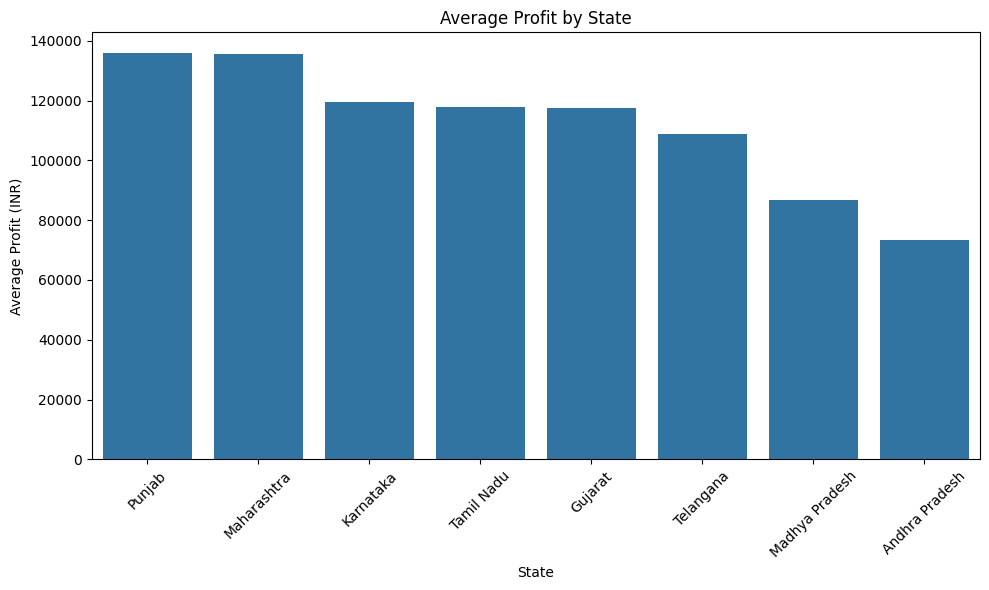

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_performance.reset_index(),
    x="State",
    y="Profit_INR",
    order=state_performance.index
)

plt.title("Average Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("Final analytical questions defined successfully.")

Final analytical questions defined successfully.


In [89]:
final_season_summary = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Profit_INR": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

final_season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,
Kharif,5.63,46.31,178914.65,5.89,54.47
Rabi,5.09,41.49,87689.47,5.19,40.48
Zaid,4.64,38.89,-24804.82,4.41,38.22


In [90]:
kharif = final_season_summary.loc["Kharif"]
zaid = final_season_summary.loc["Zaid"]

comparison = pd.DataFrame({
    "Kharif": kharif,
    "Zaid": zaid,
    "Difference": (kharif - zaid).round(2),
    "Change_%": ((kharif - zaid) / zaid.abs() * 100).round(2)
})

comparison

,Kharif,Zaid,Difference,Change_%
Yield_Tonnes_Ha,5.63,4.64,0.99,21.34
Production_Tonnes,46.31,38.89,7.42,19.08
Profit_INR,178914.65,-24804.82,203719.47,821.29
Water_Efficiency_t_per_1000m3,5.89,4.41,1.48,33.56
Disease_Pest_Risk_pct,54.47,38.22,16.25,42.52


In [91]:
crop_final_summary = df_clean.groupby("Crop").agg(
    Average_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Average_Profit_INR=("Profit_INR", "mean"),
    Average_Revenue_INR=("Revenue_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

# Profitability rate
crop_profitability = (
    df_clean.groupby("Crop")["Profit_INR"]
    .apply(lambda x: (x > 0).mean() * 100)
    .round(2)
    .rename("Profitability_Rate_pct")
)

crop_final_summary = crop_final_summary.join(crop_profitability)

crop_final_summary.sort_values(
    "Average_Profit_INR",
    ascending=False
)

,Average_Yield_Tonnes_Ha,Average_Profit_INR,Average_Revenue_INR,Average_Water_Efficiency,Profitability_Rate_pct
Crop,,,,,
Sugarcane,46.93,817187.99,1371980.11,30.48,88.52
Chilli,1.54,750878.34,1276777.23,2.95,82.04
Cotton,1.23,124546.92,639423.08,1.94,65.35
Groundnut,1.32,44858.12,542935.50,3.15,59.20
Pulses,0.92,-4238.05,528465.87,2.90,50.81
Maize,2.72,-83978.33,457067.99,5.60,36.30
Rice,2.44,-102213.50,423615.26,1.95,33.62
Wheat,2.11,-123398.34,400104.89,4.63,25.90


In [92]:
crop_final_summary.sort_values(
    "Profitability_Rate_pct",
    ascending=False
)

,Average_Yield_Tonnes_Ha,Average_Profit_INR,Average_Revenue_INR,Average_Water_Efficiency,Profitability_Rate_pct
Crop,,,,,
Sugarcane,46.93,817187.99,1371980.11,30.48,88.52
Chilli,1.54,750878.34,1276777.23,2.95,82.04
Cotton,1.23,124546.92,639423.08,1.94,65.35
Groundnut,1.32,44858.12,542935.50,3.15,59.20
Pulses,0.92,-4238.05,528465.87,2.90,50.81
Maize,2.72,-83978.33,457067.99,5.60,36.30
Rice,2.44,-102213.50,423615.26,1.95,33.62
Wheat,2.11,-123398.34,400104.89,4.63,25.90


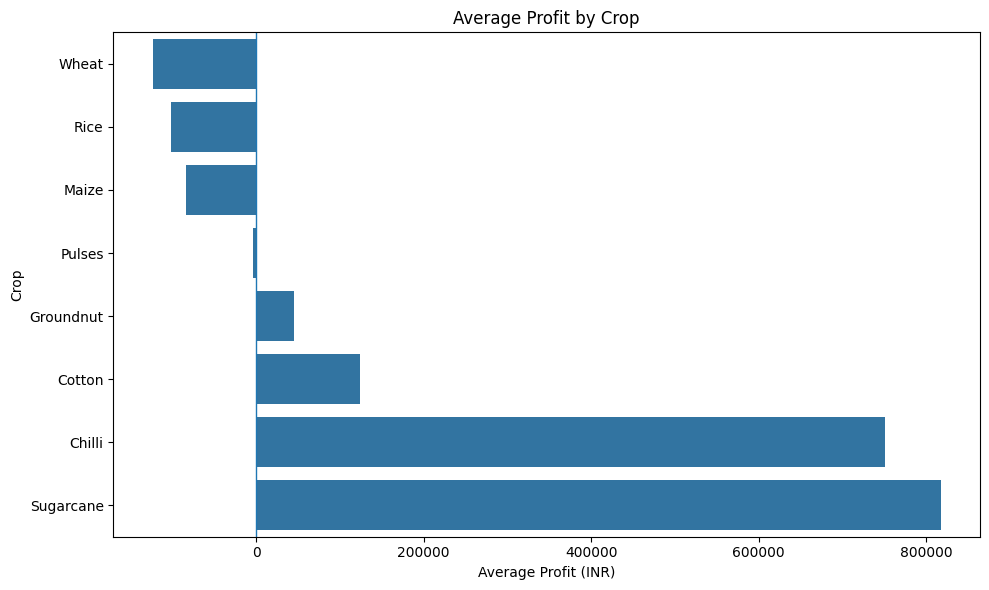

In [93]:
plt.figure(figsize=(10, 6))

crop_plot = crop_final_summary.sort_values(
    "Average_Profit_INR",
    ascending=True
)

sns.barplot(
    data=crop_plot.reset_index(),
    x="Average_Profit_INR",
    y="Crop"
)

plt.axvline(0, linewidth=1)

plt.title("Average Profit by Crop")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [94]:
crop_season_profit = df_clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).round(2)

crop_season_profit

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


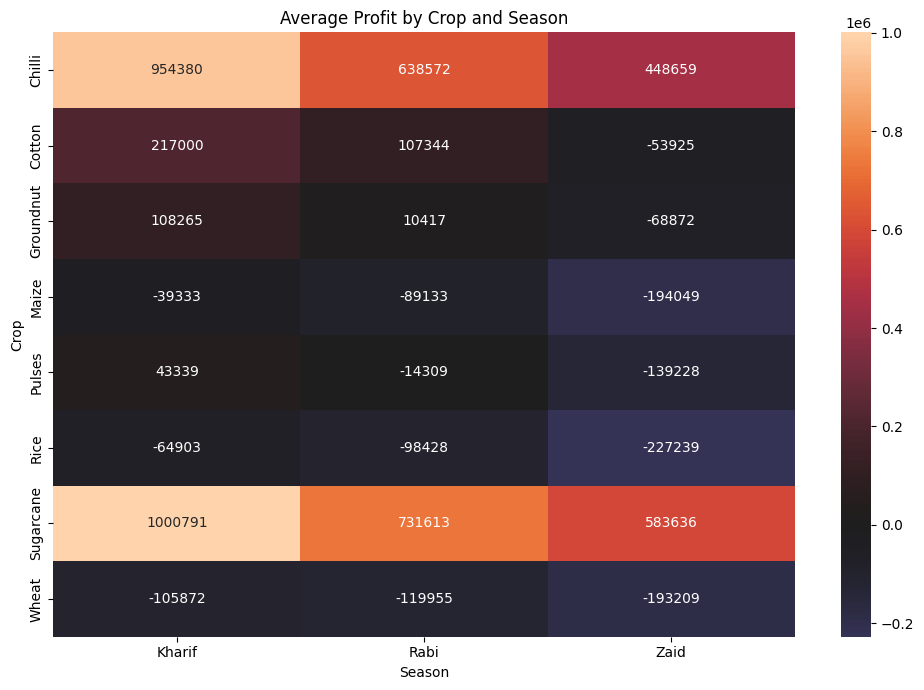

In [95]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt=".0f",
    center=0
)

plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

In [96]:
irrigation_final_summary = df_clean.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

irrigation_final_summary.sort_values(
    "Average_Profit",
    ascending=False
)

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,
Drip,6.67,219626.00,5918.75,6.27
Sprinkler,5.16,91121.08,6208.26,4.67
Rainfed,4.60,79050.37,3549.55,7.56
Flood,4.86,73354.02,8026.47,3.44


In [97]:
irrigation_final_summary = df_clean.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

irrigation_final_summary.sort_values(
    "Average_Profit",
    ascending=False
)

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency
Irrigation_Method,,,,
Drip,6.67,219626.00,5918.75,6.27
Sprinkler,5.16,91121.08,6208.26,4.67
Rainfed,4.60,79050.37,3549.55,7.56
Flood,4.86,73354.02,8026.47,3.44


In [98]:
environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct",
    "Soil_pH"
]

environmental_performance = df_clean[
    environmental_cols + ["Yield_Tonnes_Ha", "Profit_INR"]
].corr()[["Yield_Tonnes_Ha", "Profit_INR"]].round(3)

environmental_performance

,Yield_Tonnes_Ha,Profit_INR
Rainfall_mm,0.027,0.106
Avg_Temperature_C,0.009,0.009
Humidity_pct,0.011,0.064
Sunlight_Hours_Day,-0.015,-0.055
Soil_Moisture_pct,0.010,0.092
Soil_pH,-0.022,-0.013
Yield_Tonnes_Ha,1.000,0.489
Profit_INR,0.489,1.000


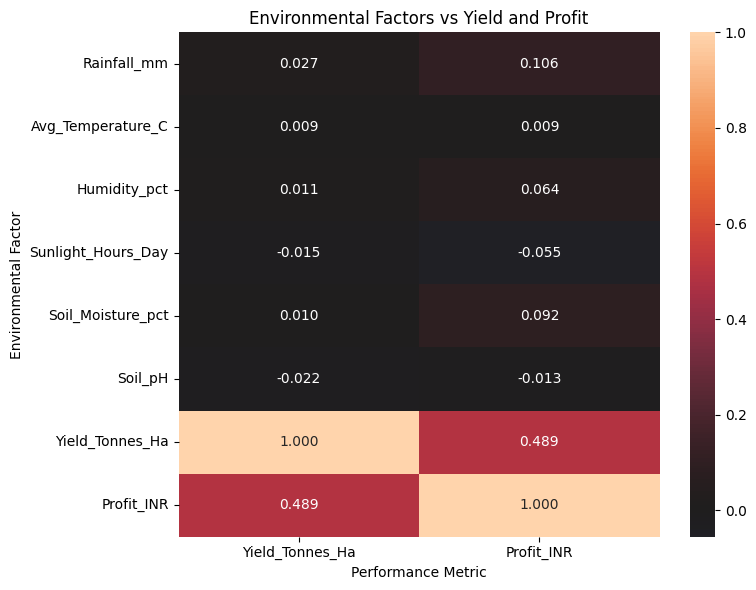

In [99]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    environmental_performance,
    annot=True,
    fmt=".3f",
    center=0
)

plt.title("Environmental Factors vs Yield and Profit")
plt.xlabel("Performance Metric")
plt.ylabel("Environmental Factor")
plt.tight_layout()
plt.show()

In [100]:
final_findings = pd.DataFrame({
    "Area": [
        "Season",
        "Crop",
        "Irrigation",
        "Water Efficiency",
        "Environmental Factors",
        "Yield-Profit Relationship"
    ],
    "Key Finding": [
        "Kharif shows the strongest overall performance.",
        "Sugarcane and Chilli are the strongest profitable crops.",
        "Drip irrigation has the highest average yield and profit.",
        "Rainfed has the highest water efficiency, while Flood has the lowest.",
        "Environmental factors show weak linear correlation with yield.",
        "Yield has a moderate positive relationship with profit."
    ],
    "Evidence": [
        "Yield: 5.63 t/ha; Profit: ₹178,914.65",
        "Sugarcane profit: ₹817,187.99; profitability: 88.52%",
        "Yield: 6.67 t/ha; Profit: ₹219,626",
        "Rainfed: 7.56; Flood: 3.44 t/1000m³",
        "All environmental–yield correlations are between -0.022 and 0.027",
        "Correlation = 0.489"
    ]
})

final_findings

,Area,Key Finding,Evidence
0,Season,Kharif shows the strongest overall performance.,"Yield: 5.63 t/ha; Profit: ₹178,914.65"
1,Crop,Sugarcane and Chilli are the strongest profita...,"Sugarcane profit: ₹817,187.99; profitability: ..."
2,Irrigation,Drip irrigation has the highest average yield ...,"Yield: 6.67 t/ha; Profit: ₹219,626"
3,Water Efficiency,"Rainfed has the highest water efficiency, whil...",Rainfed: 7.56; Flood: 3.44 t/1000m³
4,Environmental Factors,Environmental factors show weak linear correla...,All environmental–yield correlations are betwe...
5,Yield-Profit Relationship,Yield has a moderate positive relationship wit...,Correlation = 0.489


## Key Findings

The analysis produced the following major findings:

- **Seasonal performance:** Kharif has the highest average yield (5.63 tonnes/ha), production (46.31 tonnes), profit (₹178,914.65), and water efficiency (5.89 t/1000m³). Zaid has the weakest overall performance.

- **Crop profitability:** Sugarcane has the highest average profit (₹817,187.99) and profitability rate (88.52%), followed by Chilli with an average profit of ₹750,878.34 and profitability rate of 82.04%.

- **Irrigation:** Drip irrigation has the highest average yield (6.67 tonnes/ha) and average profit (₹219,626). Statistical testing confirms that irrigation method has a significant effect on yield.

- **Water efficiency:** Rainfed farming has the highest average water efficiency (7.56 t/1000m³), while Flood irrigation has the lowest (3.44 t/1000m³) and the highest average water use.

- **Crop-season profitability:** Sugarcane and Chilli remain profitable across all three seasons. Several crops, including Maize, Rice, and Wheat, show negative average profit across seasons.

- **Environmental relationships:** The environmental variables show very weak linear correlations with yield. Therefore, no strong linear relationship between individual environmental factors and yield can be established from this dataset.

- **Yield and profit:** Yield has a moderate positive correlation with profit (r = 0.489), indicating that higher yield is generally associated with higher profitability in this dataset.

## Recommendations

1. **Prioritize Kharif cultivation where suitable**
   
   Kharif shows the strongest overall performance, with the highest average yield, production, profit, and water efficiency among the three seasons.

2. **Consider Sugarcane and Chilli for profitability**
   
   Sugarcane and Chilli show the strongest profitability across seasons. Sugarcane has the highest average profit and profitability rate, while Chilli also maintains high profitability across all seasons.

3. **Prefer efficient irrigation methods**
   
   Drip irrigation provides the highest average yield and profit and shows significantly higher yield than Flood and Rainfed irrigation. Where practical, drip irrigation should be considered for improving productivity.

4. **Improve water management**
   
   Rainfed farming has the highest water efficiency, while Flood irrigation uses the most water and has the lowest water efficiency. Water-intensive irrigation practices should therefore be reviewed and optimized.

5. **Review loss-making crop-season combinations**
   
   Maize, Rice, and Wheat show negative average profit across all three seasons. Their input costs, market prices, and cultivation practices should be reviewed before large-scale cultivation.

6. **Use environmental factors as supporting indicators**
   
   Environmental variables show weak linear relationships with yield in this dataset. Therefore, crop and irrigation decisions should not be based on a single environmental variable alone.

7. **Use yield improvement as one profitability strategy**
   
   Yield and profit show a moderate positive relationship (correlation = 0.489), indicating that improving productivity can be associated with better profitability.

## Conclusion

The analysis shows that agricultural performance varies meaningfully across seasons, crops, and irrigation methods. Kharif demonstrates the strongest overall performance, while Zaid shows comparatively lower yield, production, water efficiency, and profitability.

Crop-level analysis identifies Sugarcane and Chilli as the strongest profitable crops. Sugarcane consistently provides the highest average profit across all three seasons. Irrigation analysis shows that Drip irrigation has the highest average yield and profit, while Rainfed farming has the highest water efficiency.

Statistical analysis confirms significant differences in yield across irrigation methods. Seasonal yield differences are also statistically significant after excluding Sugarcane, indicating that the seasonal pattern is not explained only by Sugarcane's unusually high yield.

Overall, the findings can support better crop selection, irrigation planning, water management, and profitability-focused agricultural decision-making.

## Limitations

- The dataset contains 4,000 observations covering 8 states, 10 districts, 8 crops, and 3 seasons.
- Some district-state combinations appear inconsistent in the dataset, so geographical conclusions should be interpreted cautiously.
- Several variables contain extreme values, particularly Yield, Production, Profit, and Water Efficiency. These were identified but not automatically removed because they may represent genuine observations.
- Correlation analysis identifies relationships but does not establish causation.
- The analysis is based on the available dataset and may not represent all agricultural regions or farming conditions.

In [104]:
print("Conclusion and limitations added successfully.")

Conclusion and limitations added successfully.


In [105]:
print("Notebook final check")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Farm_ID duplicates:", df_clean["Farm_ID"].duplicated().sum())

Notebook final check
Rows: 4000
Columns: 28
Missing values: 0
Duplicate rows: 0
Farm_ID duplicates: 0
